In [7]:

import os
import re
import json
import string
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)

# ----------------------------------------------------------------------------
CANDIDATE_INPUT_DIRS = [
    "/kaggle/input/legal-contract-dataset",
    "/kaggle/input/legal-contracts-dataset",
    "/kaggle/input",   # fallback: search recursively under /kaggle/input
    ".",               # local / non-Kaggle fallback
]

FILENAMES = {
    "complete_json": "complete.json",
    "reshaped_clauses_csv": "all_reshaped_clauses.csv",
    "clause_boundary_csv": "clause_boundary_data.csv",
}

OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
DATASET_CSV_PATH = os.path.join(OUTPUT_DIR, "workflow_dataset.csv")
RULES_JSON_PATH = os.path.join(OUTPUT_DIR, "workflow_rules.json")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Output directory:", OUTPUT_DIR)


Output directory: /kaggle/working


In [8]:

def locate_file(filename, search_roots=CANDIDATE_INPUT_DIRS):
    """
    Deterministically locate `filename` by checking each candidate root directly,
    then falling back to a recursive search under /kaggle/input.
    Returns the first match found (str path) or raises FileNotFoundError.
    """
    for root in search_roots:
        direct = os.path.join(root, filename)
        if os.path.isfile(direct):
            return direct

    # Recursive fallback search under /kaggle/input (handles nested dataset folders)
    for root in ["/kaggle/input", "."]:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, files in os.walk(root):
            if filename in files:
                return os.path.join(dirpath, filename)

    raise FileNotFoundError(
        f"Could not locate '{filename}'. Attach the 'Legal Contract Dataset' as a Kaggle "
        f"data source, or place the file in the working directory."
    )

COMPLETE_JSON_PATH = locate_file(FILENAMES["complete_json"])
RESHAPED_CLAUSES_CSV_PATH = locate_file(FILENAMES["reshaped_clauses_csv"])
CLAUSE_BOUNDARY_CSV_PATH = locate_file(FILENAMES["clause_boundary_csv"])

print("complete.json           ->", COMPLETE_JSON_PATH)
print("all_reshaped_clauses.csv ->", RESHAPED_CLAUSES_CSV_PATH)
print("clause_boundary_data.csv ->", CLAUSE_BOUNDARY_CSV_PATH)


complete.json           -> /kaggle/input/datasets/changethan/legal-contract-dataset/complete.json
all_reshaped_clauses.csv -> /kaggle/input/datasets/changethan/legal-contract-dataset/all_reshaped_clauses.csv
clause_boundary_data.csv -> /kaggle/input/datasets/changethan/legal-contract-dataset/clause_boundary_data.csv


In [9]:

with open(COMPLETE_JSON_PATH, "r", encoding="utf-8") as f:
    raw_complete = json.load(f)

print("Top-level type:", type(raw_complete))

if isinstance(raw_complete, dict):
    print("Top-level keys:", list(raw_complete.keys())[:20])
    # Some exports wrap the record list under a key like "data" / "contracts" / "documents"
    list_key = None
    for k, v in raw_complete.items():
        if isinstance(v, list) and len(v) > 0:
            list_key = k
            break
    if list_key is not None:
        records = raw_complete[list_key]
        print(f"Using nested list found under key '{list_key}' with {len(records)} records")
    else:
        # Treat the dict itself as {contract_id: record}
        records = [{"_id": k, **(v if isinstance(v, dict) else {"value": v})}
                   for k, v in raw_complete.items()]
        print(f"Treating top-level dict as {{id: record}} map -> {len(records)} records")
elif isinstance(raw_complete, list):
    records = raw_complete
    print(f"Top-level list with {len(records)} records")
else:
    raise ValueError("Unexpected complete.json structure — expected list or dict at top level.")

print("\nSample record (first item), keys only:")
print(list(records[0].keys()) if isinstance(records[0], dict) else type(records[0]))


Top-level type: <class 'list'>
Top-level list with 1117 records

Sample record (first item), keys only:
['id', 'file_name', 'full_text', 'full_text_topic_num', 'full_text_topic_label', 'lines', 'lines_topic_num', 'line_topic_label']


In [10]:

# ----------------------------------------------------------------------------
# Auto-detect the identifier field and the full-text field from the record schema
# ----------------------------------------------------------------------------
ID_FIELD_CANDIDATES = ["id", "doc_id", "document_id", "contract_id", "filename", "file_name", "title", "name"]
TEXT_FIELD_CANDIDATES = ["contract_text", "text", "context", "document_text", "full_text", "content", "body"]
CLAUSES_FIELD_CANDIDATES = ["clauses", "clause_list", "annotations", "labels"]

sample_keys = set()
for r in records[:50]:
    if isinstance(r, dict):
        sample_keys.update(r.keys())

def pick_field(candidates, available_keys, required=True, field_desc=""):
    for c in candidates:
        if c in available_keys:
            return c
    if required:
        raise KeyError(
            f"Could not auto-detect the {field_desc} field. "
            f"Looked for {candidates} but found only {sorted(available_keys)}. "
            f"Update TEXT_FIELD_CANDIDATES / ID_FIELD_CANDIDATES with the correct key name."
        )
    return None

ID_FIELD = pick_field(ID_FIELD_CANDIDATES, sample_keys, required=False, field_desc="contract identifier")
TEXT_FIELD = pick_field(TEXT_FIELD_CANDIDATES, sample_keys, required=True, field_desc="full contract text")
CLAUSES_FIELD = pick_field(CLAUSES_FIELD_CANDIDATES, sample_keys, required=False, field_desc="clause list")

print("Detected ID field:      ", ID_FIELD)
print("Detected TEXT field:    ", TEXT_FIELD)
print("Detected CLAUSES field: ", CLAUSES_FIELD)


Detected ID field:       id
Detected TEXT field:     full_text
Detected CLAUSES field:  None


In [11]:

def extract_text(value):
    """complete.json sometimes stores text as a plain string, sometimes as a list of paragraph strings."""
    if isinstance(value, str):
        return value
    if isinstance(value, list):
        return "\n".join(str(v) for v in value if isinstance(v, (str, int, float)))
    return "" if value is None else str(value)

def extract_clause_types(record):
    """Best-effort extraction of clause type labels embedded directly in a complete.json record."""
    if CLAUSES_FIELD is None or CLAUSES_FIELD not in record:
        return []
    raw = record[CLAUSES_FIELD]
    types = []
    if isinstance(raw, list):
        for item in raw:
            if isinstance(item, dict):
                for key in ("clause_type", "type", "category", "label"):
                    if key in item and item[key]:
                        types.append(str(item[key]))
                        break
            elif isinstance(item, str):
                types.append(item)
    elif isinstance(raw, dict):
        types.extend([str(k) for k in raw.keys()])
    return types

rows = []
for i, r in enumerate(records):
    if not isinstance(r, dict):
        continue
    doc_id = str(r.get(ID_FIELD, f"doc_{i}")) if ID_FIELD else f"doc_{i}"
    text = extract_text(r.get(TEXT_FIELD, ""))
    clause_types = extract_clause_types(r)
    rows.append({"doc_id": doc_id, "raw_text": text, "embedded_clause_types": clause_types})

df_complete = pd.DataFrame(rows)
print("Loaded", len(df_complete), "contracts from complete.json")
df_complete.head(3)


Loaded 1117 contracts from complete.json


,doc_id,raw_text,embedded_clause_types
0,0,-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT en...,[]
1,1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AG...",[]
2,10,"CO-BRANDING AND ADVERTISING AGREEMENT\n\nTHIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of ...",[]


In [12]:

df_clauses = pd.read_csv(RESHAPED_CLAUSES_CSV_PATH)
df_boundary = pd.read_csv(CLAUSE_BOUNDARY_CSV_PATH)

print("all_reshaped_clauses.csv shape:", df_clauses.shape)
print("Columns:", list(df_clauses.columns))
display(df_clauses.head(3))

print("\nclause_boundary_data.csv shape:", df_boundary.shape)
print("Columns:", list(df_boundary.columns))
display(df_boundary.head(3))


all_reshaped_clauses.csv shape: (8628, 3)
Columns: ['filename', 'clause_type', 'clause_text']


,filename,clause_type,clause_text
0,GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10.1_Content License Agreement.pdf,Change of Control,"For purposes of the preceding sentence, and without limiting its generality, any merger, consolidation or reorganiza..."
1,DeltathreeInc_19991102_S-1A_EX-10.19_6227850_EX-10.19_Co-Branding Agreement_ Service Agreement.pdf,Change of Control,The term of this Agreement shall be effective as of the date first stated above and shall continue for a term of thr...
2,EdietsComInc_20001030_10QSB_EX-10.4_2606646_EX-10.4_Co-Branding Agreement.pdf,Change of Control,"For purposes of this Agreement, ""Change in Control"" means a merger or consolidation of the party with, or any sale o..."



clause_boundary_data.csv shape: (42282, 2)
Columns: ['filename', 'clause_text']


,filename,clause_text
0,064-19 Non Disclosure Agreement 2019.pdf,NON-DISCLOSURE AGREEMENT
1,064-19 Non Disclosure Agreement 2019.pdf,Required under JEA's Confidential Information Protection Program
2,064-19 Non Disclosure Agreement 2019.pdf,"THIS NON-DISCLOSURE AGREEMENT (""Agreement"") is entered into this ______day of"


In [13]:

# ----------------------------------------------------------------------------
# Build a per-contract set of clause types by joining the reshaped-clauses CSV
# on whichever column overlaps with df_complete's doc_id values.
# This is a supporting signal for the rule engine (Section 5) — never used to
# alter or generate contract_text.
# ----------------------------------------------------------------------------
CLAUSE_ID_COL_CANDIDATES = ["doc_id", "document_id", "contract_id", "filename", "file_name", "title", "name", "id"]
CLAUSE_TYPE_COL_CANDIDATES = ["clause_type", "type", "category", "label", "clause_category"]

def pick_csv_field(df, candidates, field_desc):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find a {field_desc} column in {list(df.columns)}")

clause_id_col = pick_csv_field(df_clauses, CLAUSE_ID_COL_CANDIDATES, "contract identifier")
clause_type_col = pick_csv_field(df_clauses, CLAUSE_TYPE_COL_CANDIDATES, "clause type")

print("Joining clauses CSV on:", clause_id_col, "| clause type column:", clause_type_col)

clause_map = (
    df_clauses.dropna(subset=[clause_id_col, clause_type_col])
    .groupby(df_clauses[clause_id_col].astype(str))[clause_type_col]
    .apply(lambda s: sorted(set(s.astype(str))))
    .to_dict()
)

def lookup_clause_types(doc_id):
    return clause_map.get(str(doc_id), [])

df_complete["csv_clause_types"] = df_complete["doc_id"].apply(lookup_clause_types)

# Merge embedded + CSV-derived clause types into one canonical list per contract
df_complete["clause_types"] = df_complete.apply(
    lambda row: sorted(set(row["embedded_clause_types"]) | set(row["csv_clause_types"])), axis=1
)

n_matched = (df_complete["clause_types"].str.len() > 0).sum()
print(f"{n_matched}/{len(df_complete)} contracts have at least one identified clause type.")


Joining clauses CSV on: filename | clause type column: clause_type
0/1117 contracts have at least one identified clause type.


In [14]:

print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)
print(df_complete.info())
print("\nShape:", df_complete.shape)
df_complete.describe(include="all").T


DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117 entries, 0 to 1116
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   doc_id                 1117 non-null   object
 1   raw_text               1117 non-null   object
 2   embedded_clause_types  1117 non-null   object
 3   csv_clause_types       1117 non-null   object
 4   clause_types           1117 non-null   object
dtypes: object(5)
memory usage: 43.8+ KB
None

Shape: (1117, 5)


,count,unique,top,freq
doc_id,1117,618,94,2
raw_text,1117,1115,"DEPARTMENT OF HOMELAND SECURITY\nNON-DISCLOSURE AGREEMENT\nI, _______________________________________, an individual...",2
embedded_clause_types,1117,1,[],1117
csv_clause_types,1117,1,[],1117
clause_types,1117,1,[],1117


In [15]:

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)
missing = df_complete.isna().sum()
missing_pct = (missing / len(df_complete) * 100).round(2)
empty_text = (df_complete["raw_text"].astype(str).str.strip() == "").sum()

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
})
missing_report.loc["raw_text_empty_string"] = [empty_text, round(empty_text / len(df_complete) * 100, 2)]
display(missing_report)


MISSING VALUES


,missing_count,missing_pct
doc_id,0.0,0.0
raw_text,0.0,0.0
embedded_clause_types,0.0,0.0
csv_clause_types,0.0,0.0
clause_types,0.0,0.0
raw_text_empty_string,0.0,0.0


In [16]:

print("=" * 70)
print("DUPLICATES")
print("=" * 70)
dup_exact = df_complete.duplicated(subset=["raw_text"]).sum()
dup_id = df_complete.duplicated(subset=["doc_id"]).sum()
print(f"Exact duplicate contract texts : {dup_exact}")
print(f"Duplicate doc_id values        : {dup_id}")


DUPLICATES
Exact duplicate contract texts : 2
Duplicate doc_id values        : 499


TEXT LENGTH DISTRIBUTION (raw, pre-cleaning)


,char_len,word_len
count,1117.000000,1117.000000
mean,30079.332140,4510.824530
std,43332.873567,6478.033756
min,645.000000,109.000000
25%,7930.000000,1183.000000
50%,14075.000000,2106.000000
75%,30127.000000,4601.000000
max,338211.000000,47733.000000


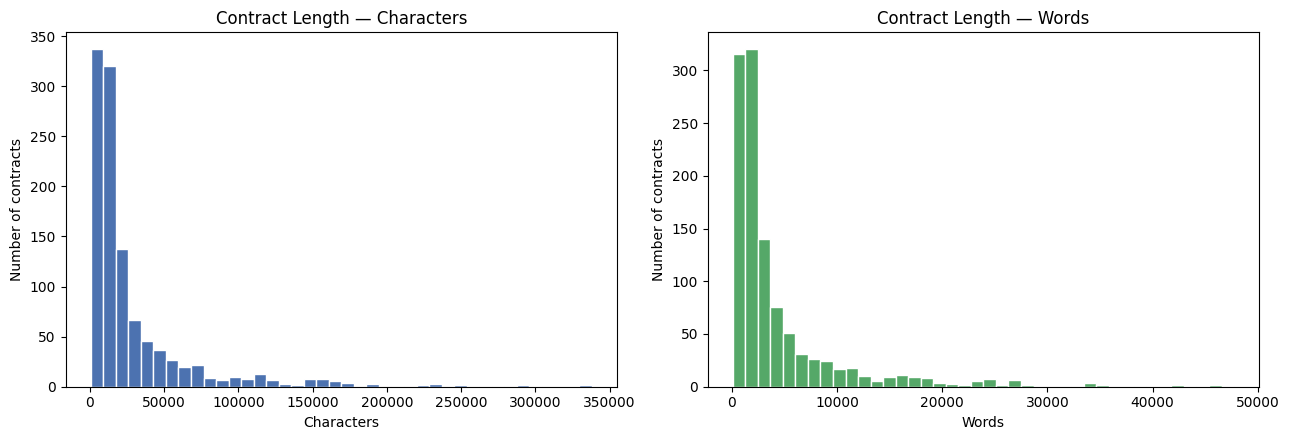

In [17]:

print("=" * 70)
print("TEXT LENGTH DISTRIBUTION (raw, pre-cleaning)")
print("=" * 70)
df_complete["char_len"] = df_complete["raw_text"].astype(str).str.len()
df_complete["word_len"] = df_complete["raw_text"].astype(str).str.split().str.len()

display(df_complete[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df_complete["char_len"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Contract Length — Characters")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Number of contracts")

axes[1].hist(df_complete["word_len"], bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Contract Length — Words")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Number of contracts")

plt.tight_layout()
plt.show()


CLAUSE DISTRIBUTION (from all_reshaped_clauses.csv)
Total clause instances: 8628
Unique clause types:    47


clause_type
Document Name                  510
Parties-Answer                 509
Parties                        509
Agreement Date                 470
Agreement Date-Answer          465
Governing Law                  437
Expiration Date                413
Effective Date                 390
Anti-assignment                374
Effective Date-Answer          359
Expiration Date-Answer         329
Cap on Liability               275
License Grant                  255
Audit Rights                   214
Termination for Convenience    183
Post-termination Services      182
Exclusivity                    180
Renewal Term                   176
Revenue-Profit Sharing         166
Insurance                      166
Name: count, dtype: int64

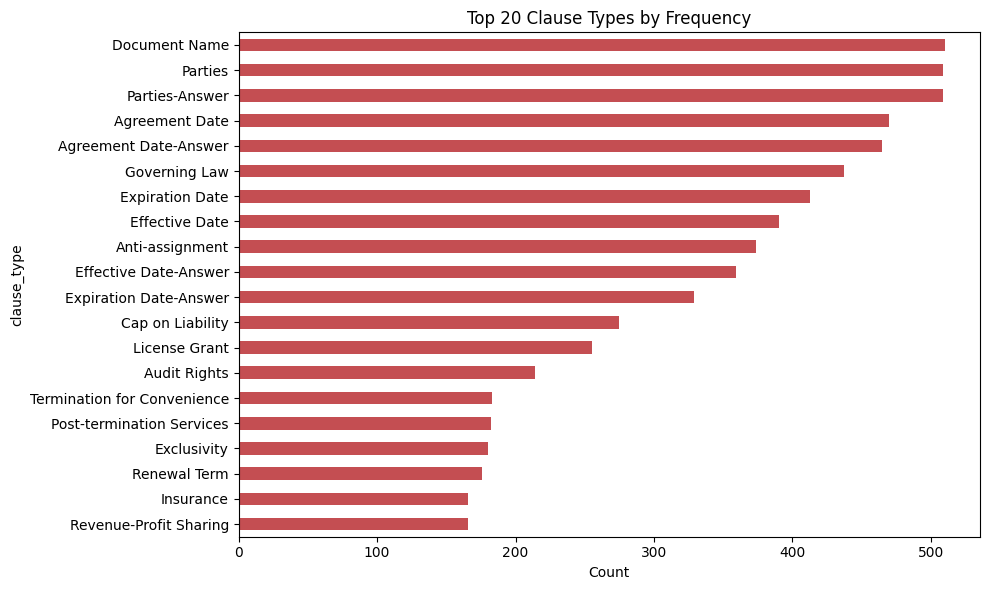

In [18]:

print("=" * 70)
print("CLAUSE DISTRIBUTION (from all_reshaped_clauses.csv)")
print("=" * 70)
clause_counts = df_clauses[clause_type_col].astype(str).value_counts()
print(f"Total clause instances: {len(df_clauses)}")
print(f"Unique clause types:    {clause_counts.shape[0]}")
display(clause_counts.head(20))

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
clause_counts.head(top_n).sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title(f"Top {top_n} Clause Types by Frequency")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


CONTRACT DISTRIBUTION — number of distinct clause types per contract


count    1117.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: n_clause_types, dtype: float64

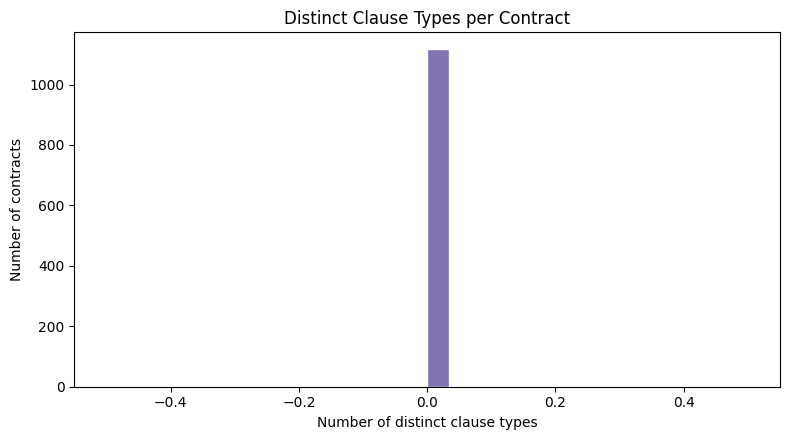

In [19]:

print("=" * 70)
print("CONTRACT DISTRIBUTION — number of distinct clause types per contract")
print("=" * 70)
df_complete["n_clause_types"] = df_complete["clause_types"].str.len()
display(df_complete["n_clause_types"].describe())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_complete["n_clause_types"], bins=30, color="#8172B2", edgecolor="white")
ax.set_title("Distinct Clause Types per Contract")
ax.set_xlabel("Number of distinct clause types")
ax.set_ylabel("Number of contracts")
plt.tight_layout()
plt.show()


In [20]:

def clean_contract_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)
    # Remove non-printable / control characters (keep newlines/tabs before collapsing)
    text = "".join(ch for ch in text if ch in "\n\t" or ch >= " ")
    # Collapse all whitespace runs (including newlines/tabs) into a single space
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_clean = df_complete.copy()
df_clean["contract_text"] = df_clean["raw_text"].apply(clean_contract_text)

n_before = len(df_clean)

# Remove empty contracts
df_clean = df_clean[df_clean["contract_text"].str.len() > 0].copy()
n_after_empty = len(df_clean)

# Remove exact duplicate contract texts, keep first occurrence
df_clean = df_clean.drop_duplicates(subset=["contract_text"], keep="first").copy()
n_after_dedup = len(df_clean)

print(f"Contracts before cleaning        : {n_before}")
print(f"After removing empty contracts   : {n_after_empty}  (-{n_before - n_after_empty})")
print(f"After removing duplicate texts   : {n_after_dedup}  (-{n_after_empty - n_after_dedup})")

df_clean = df_clean.reset_index(drop=True)
df_clean[["doc_id", "contract_text"]].head(3)


Contracts before cleaning        : 1117
After removing empty contracts   : 1117  (-0)
After removing duplicate texts   : 1113  (-4)


,doc_id,contract_text
0,0,-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS ...
1,1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGRE..."
2,10,"CO-BRANDING AND ADVERTISING AGREEMENT THIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of Jun..."


In [21]:

# ----------------------------------------------------------------------------
# Rule definitions. Each rule is a dict: workflow_id, description, and the
# regex pattern(s) used against (a) the title window and (b) the full text.
# Clause-type keyword sets are used only as tie-breaker / disambiguation
# signals for WF_EXECUTIVE vs WF_EMPLOYMENT and WF_PROCUREMENT vs WF_VENDOR/WF_PURCHASE.
# ----------------------------------------------------------------------------

TITLE_WINDOW_CHARS = 500

EXECUTIVE_PATTERN = re.compile(
    r"\b(chief executive officer|chief financial officer|chief operating officer|"
    r"chief technology officer|president and ceo|executive employment agreement|"
    r"employment agreement.{0,80}\b(chairman|president)\b|golden parachute)\b",
    re.IGNORECASE,
)
EXECUTIVE_CLAUSE_HINTS = {"change of control", "change-of-control", "severance", "golden parachute"}

EMPLOYMENT_PATTERN = re.compile(
    r"\b(employment agreement|offer of employment|employment contract|at-will employment|"
    r"terms of employment)\b",
    re.IGNORECASE,
)

NDA_PATTERN = re.compile(
    r"\b(non-disclosure agreement|nondisclosure agreement|non disclosure agreement|\bnda\b|"
    r"mutual confidentiality agreement|confidentiality agreement)\b",
    re.IGNORECASE,
)

SERVICE_PATTERN = re.compile(
    r"\b(services agreement|service agreement|consulting agreement|master service agreement|\bmsa\b|"
    r"professional services agreement|independent contractor agreement)\b",
    re.IGNORECASE,
)

PROCUREMENT_PATTERN = re.compile(
    r"\b(procurement agreement|sourcing agreement|framework agreement|master purchase agreement|"
    r"purchasing agreement)\b",
    re.IGNORECASE,
)
PROCUREMENT_CLAUSE_HINTS = {"minimum commitment", "volume restriction", "price restriction", "most favored nation"}

VENDOR_PATTERN = re.compile(
    r"\b(vendor agreement|supplier agreement|distributor agreement|reseller agreement|supply agreement)\b",
    re.IGNORECASE,
)

PURCHASE_PATTERN = re.compile(
    r"\b(purchase agreement|asset purchase agreement|stock purchase agreement|sale and purchase agreement|"
    r"purchase order\b)\b",
    re.IGNORECASE,
)

RULES = [
    {
        "priority": 1,
        "workflow_id": "WF_EXECUTIVE",
        "description": (
            "Fires when the title/text names a C-level officer role (CEO/CFO/COO/CTO), an explicit "
            "'executive employment agreement', an employment agreement combined with Chairman/President "
            "title, or 'golden parachute' language. Also fires when general employment language "
            "co-occurs with change-of-control/severance clause types, which typically indicate an "
            "executive-tier employment contract rather than a standard employment contract."
        ),
    },
    {
        "priority": 2,
        "workflow_id": "WF_EMPLOYMENT",
        "description": (
            "Fires when the title/text matches general employment-agreement language "
            "('employment agreement', 'offer of employment', 'at-will employment', etc.) and the "
            "WF_EXECUTIVE rule did not already fire."
        ),
    },
    {
        "priority": 3,
        "workflow_id": "WF_NDA",
        "description": (
            "Fires when the title/text matches non-disclosure / confidentiality agreement language "
            "('non-disclosure agreement', 'NDA', 'confidentiality agreement', 'mutual confidentiality "
            "agreement')."
        ),
    },
    {
        "priority": 4,
        "workflow_id": "WF_SERVICE",
        "description": (
            "Fires when the title/text matches services/consulting agreement language "
            "('services agreement', 'consulting agreement', 'master service agreement', 'MSA', "
            "'professional services agreement', 'independent contractor agreement')."
        ),
    },
    {
        "priority": 5,
        "workflow_id": "WF_PROCUREMENT",
        "description": (
            "Fires when the title/text explicitly matches procurement/sourcing/framework agreement "
            "language, OR when purchase/vendor-style language is present together with procurement-"
            "typical clause types (minimum commitment, volume restriction, price restriction, "
            "most-favored-nation) — distinguishing bulk/recurring procurement arrangements from a "
            "one-off purchase or a standard vendor relationship."
        ),
    },
    {
        "priority": 6,
        "workflow_id": "WF_VENDOR",
        "description": (
            "Fires when the title/text matches vendor/supplier/distributor/reseller agreement language "
            "('vendor agreement', 'supplier agreement', 'distributor agreement', 'reseller agreement', "
            "'supply agreement')."
        ),
    },
    {
        "priority": 7,
        "workflow_id": "WF_PURCHASE",
        "description": (
            "Fires when the title/text matches purchase/sale agreement language "
            "('purchase agreement', 'asset purchase agreement', 'stock purchase agreement', "
            "'sale and purchase agreement', 'purchase order')."
        ),
    },
    {
        "priority": 8,
        "workflow_id": "WF_GENERAL",
        "description": (
            "Default fallback — assigned when no higher-priority rule matched. Covers contracts whose "
            "type could not be determined from title, body text, or clause-type signals (e.g. generic "
            "'AGREEMENT' titles, heavily redacted documents, or contract types outside the eight "
            "supported workflow categories)."
        ),
    },
]

def assign_workflow_id(contract_text: str, clause_types: list) -> str:
    """
    Deterministic rule engine. Same input always produces the same output.
    Priority order (first match wins) is documented in RULES above.
    """
    title_window = contract_text[:TITLE_WINDOW_CHARS]
    haystacks = (title_window, contract_text)  # check title window first implicitly via 'any'
    clause_set = {c.lower() for c in clause_types}

    def matches(pattern):
        return any(pattern.search(h) for h in haystacks)

    # 1. WF_EXECUTIVE
    if matches(EXECUTIVE_PATTERN):
        return "WF_EXECUTIVE"
    if matches(EMPLOYMENT_PATTERN) and (clause_set & EXECUTIVE_CLAUSE_HINTS):
        return "WF_EXECUTIVE"

    # 2. WF_EMPLOYMENT
    if matches(EMPLOYMENT_PATTERN):
        return "WF_EMPLOYMENT"

    # 3. WF_NDA
    if matches(NDA_PATTERN):
        return "WF_NDA"

    # 4. WF_SERVICE
    if matches(SERVICE_PATTERN):
        return "WF_SERVICE"

    # 5. WF_PROCUREMENT
    if matches(PROCUREMENT_PATTERN):
        return "WF_PROCUREMENT"
    if (matches(PURCHASE_PATTERN) or matches(VENDOR_PATTERN)) and (clause_set & PROCUREMENT_CLAUSE_HINTS):
        return "WF_PROCUREMENT"

    # 6. WF_VENDOR
    if matches(VENDOR_PATTERN):
        return "WF_VENDOR"

    # 7. WF_PURCHASE
    if matches(PURCHASE_PATTERN):
        return "WF_PURCHASE"

    # 8. WF_GENERAL (default)
    return "WF_GENERAL"

ALLOWED_WORKFLOW_IDS = {
    "WF_GENERAL", "WF_NDA", "WF_SERVICE", "WF_PURCHASE",
    "WF_EMPLOYMENT", "WF_VENDOR", "WF_PROCUREMENT", "WF_EXECUTIVE",
}

df_clean["workflow_id"] = df_clean.apply(
    lambda row: assign_workflow_id(row["contract_text"], row["clause_types"]), axis=1
)

assert set(df_clean["workflow_id"].unique()).issubset(ALLOWED_WORKFLOW_IDS), \
    "Rule engine produced a workflow_id outside the allowed set!"

print("Workflow ID assignment complete.")
df_clean[["doc_id", "workflow_id"]].head(10)


Workflow ID assignment complete.


,doc_id,workflow_id
0,0,WF_GENERAL
1,1,WF_VENDOR
2,10,WF_GENERAL
3,100,WF_NDA
4,101,WF_SERVICE
5,102,WF_GENERAL
6,103,WF_SERVICE
7,104,WF_PURCHASE
8,105,WF_PURCHASE
9,106,WF_EXECUTIVE


In [22]:

label_counts = df_clean["workflow_id"].value_counts().reindex(sorted(ALLOWED_WORKFLOW_IDS), fill_value=0)
label_pct = (label_counts / label_counts.sum() * 100).round(2)

label_summary = pd.DataFrame({"count": label_counts, "pct_of_dataset": label_pct})
label_summary


,count,pct_of_dataset
workflow_id,,
WF_EMPLOYMENT,9,0.81
WF_EXECUTIVE,265,23.81
WF_GENERAL,209,18.78
WF_NDA,527,47.35
WF_PROCUREMENT,1,0.09
WF_PURCHASE,30,2.70
WF_SERVICE,37,3.32
WF_VENDOR,35,3.14


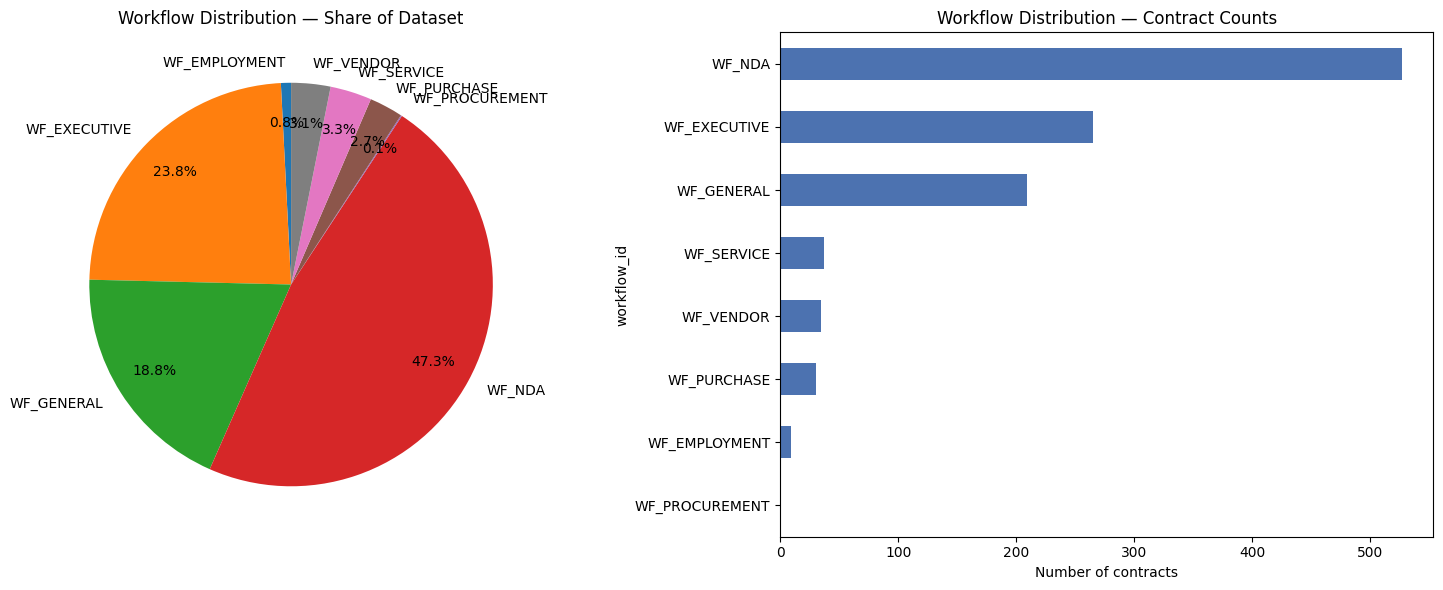

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

nonzero = label_counts[label_counts > 0]
axes[0].pie(
    nonzero.values,
    labels=nonzero.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
)
axes[0].set_title("Workflow Distribution — Share of Dataset")

label_counts.sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Workflow Distribution — Contract Counts")
axes[1].set_xlabel("Number of contracts")

plt.tight_layout()
plt.show()


In [24]:

print("=" * 70)
print("CLASS IMBALANCE DISCUSSION")
print("=" * 70)

majority_label = label_counts.idxmax()
minority_label = label_counts[label_counts > 0].idxmin() if (label_counts > 0).any() else None
imbalance_ratio = (
    label_counts.max() / label_counts[label_counts > 0].min()
    if (label_counts > 0).any() and label_counts[label_counts > 0].min() > 0
    else float("nan")
)

print(f"Majority class : {majority_label}  ({label_counts.max()} contracts)")
if minority_label is not None:
    print(f"Minority class : {minority_label}  ({label_counts[minority_label]} contracts)")
print(f"Imbalance ratio (majority / minority): {imbalance_ratio:.1f}x")
zero_classes = label_counts[label_counts == 0].index.tolist()
if zero_classes:
    print(f"Classes with zero examples in this corpus: {zero_classes}")

print("""
Why imbalance is expected here:
- The source corpus is a general-purpose commercial-contract collection, not a corpus curated to have
  equal representation across the eight target workflow categories. Some contract types (e.g. general
  commercial agreements, NDAs, and services agreements) are simply far more common in typical legal
  corpora than others (e.g. executive employment agreements, which are comparatively rare).
- WF_GENERAL absorbs every contract that the deterministic rules could not confidently map to one of the
  seven specific categories, so it will tend to be over-represented unless the source corpus's titles are
  highly structured.
- WF_EXECUTIVE and WF_PROCUREMENT are intentionally narrow, high-precision rules (they require specific
  officer-level or procurement-specific language/clause signals), so they are expected to have the fewest
  matches — this is a precision-over-recall design choice to avoid mislabeling ordinary employment or
  purchase contracts as executive/procurement.

Downstream implications for the classification model (out of scope for this notebook, noted for the
training team): consider class-weighted loss, stratified train/val/test splits, and/or oversampling of
minority workflow classes when fine-tuning.
""")


CLASS IMBALANCE DISCUSSION
Majority class : WF_NDA  (527 contracts)
Minority class : WF_PROCUREMENT  (1 contracts)
Imbalance ratio (majority / minority): 527.0x

Why imbalance is expected here:
- The source corpus is a general-purpose commercial-contract collection, not a corpus curated to have
  equal representation across the eight target workflow categories. Some contract types (e.g. general
  commercial agreements, NDAs, and services agreements) are simply far more common in typical legal
  corpora than others (e.g. executive employment agreements, which are comparatively rare).
- WF_GENERAL absorbs every contract that the deterministic rules could not confidently map to one of the
  seven specific categories, so it will tend to be over-represented unless the source corpus's titles are
  highly structured.
- WF_EXECUTIVE and WF_PROCUREMENT are intentionally narrow, high-precision rules (they require specific
  officer-level or procurement-specific language/clause signals), so they 

In [25]:

final_df = df_clean[["contract_text", "workflow_id"]].copy()

# Final integrity checks
assert final_df.columns.tolist() == ["contract_text", "workflow_id"], "Column schema mismatch"
assert final_df["contract_text"].str.len().gt(0).all(), "Empty contract_text values remain"
assert final_df["workflow_id"].isin(ALLOWED_WORKFLOW_IDS).all(), "Invalid workflow_id values present"
assert not final_df["contract_text"].duplicated().any(), "Duplicate contract_text rows remain"

print(f"Final dataset shape: {final_df.shape}")
final_df.head(5)


Final dataset shape: (1113, 2)


,contract_text,workflow_id
0,-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS ...,WF_GENERAL
1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGRE...",WF_VENDOR
2,"CO-BRANDING AND ADVERTISING AGREEMENT THIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of Jun...",WF_GENERAL
3,"Exhibit 10.19 JOINT CONTENT LICENSE AGREEMENT This JOINT CONTENT LICENSE AGREEMENT (the ""Agreement""), dated February...",WF_NDA
4,EXHIBIT 4.25 INFORMATION IN THIS EXHIBIT IDENTIFIED BY [ * * * ] IS CONFIDENTIAL AND HAS BEEN EXCLUDED BECAUSE IT IS...,WF_SERVICE


In [35]:

final_df.to_csv(DATASET_CSV_PATH, index=False, encoding="utf-8")
print(f"Saved: {DATASET_CSV_PATH}  ({os.path.getsize(DATASET_CSV_PATH):,} bytes)")

rules_export = {
    "project": "Contract Workflow Intelligence System",
    "module": "Workflow Recommendation",
    "allowed_workflow_ids": sorted(ALLOWED_WORKFLOW_IDS),
    "matching_config": {
        "title_window_chars": TITLE_WINDOW_CHARS,
        "case_sensitive": False,
        "signals_used": [
            "title_window (first N chars of cleaned contract_text)",
            "full_contract_text",
            "clause_type_set (from complete.json + all_reshaped_clauses.csv)",
        ],
    },
    "rule_priority_order": [r["workflow_id"] for r in RULES],
    "rules": [
        {
            "priority": r["priority"],
            "workflow_id": r["workflow_id"],
            "description": r["description"],
        }
        for r in RULES
    ],
    "regex_patterns": {
        "WF_EXECUTIVE": EXECUTIVE_PATTERN.pattern,
        "WF_EMPLOYMENT": EMPLOYMENT_PATTERN.pattern,
        "WF_NDA": NDA_PATTERN.pattern,
        "WF_SERVICE": SERVICE_PATTERN.pattern,
        "WF_PROCUREMENT": PROCUREMENT_PATTERN.pattern,
        "WF_VENDOR": VENDOR_PATTERN.pattern,
        "WF_PURCHASE": PURCHASE_PATTERN.pattern,
    },
    "clause_type_tie_breakers": {
        "WF_EXECUTIVE": sorted(EXECUTIVE_CLAUSE_HINTS),
        "WF_PROCUREMENT": sorted(PROCUREMENT_CLAUSE_HINTS),
    },
    "default_label": "WF_GENERAL",
    "label_distribution": label_counts.to_dict(),
}

with open(RULES_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(rules_export, f, indent=2, ensure_ascii=False)

print(f"Saved: {RULES_JSON_PATH}  ({os.path.getsize(RULES_JSON_PATH):,} bytes)")


Saved: /kaggle/working/workflow_dataset.csv  (32,546,065 bytes)
Saved: /kaggle/working/workflow_rules.json  (5,332 bytes)


In [36]:
!pip install -q -U transformers datasets accelerate evaluate scikit-learn sentencepiece huggingface_hub

In [37]:
import os
import json
import re
import unicodedata

import numpy as np
import pandas as pd

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = "/kaggle/working/workflow_dataset.csv"
RULES_PATH = "/kaggle/working/workflow_rules.json"
MODEL_NAME = "microsoft/deberta-v3-base"
OUTPUT_DIR = "/kaggle/working/workflow-recommendation-model"
MAX_LENGTH = 512

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [38]:
df = pd.read_csv(DATA_PATH)

with open(RULES_PATH, "r", encoding="utf-8") as f:
    workflow_rules = json.load(f)

assert "contract_text" in df.columns, "Missing 'contract_text' column"
assert "workflow_id" in df.columns, "Missing 'workflow_id' column"

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1113, 2)


,contract_text,workflow_id
0,-1 - TELKOM CONTRACT No. 076C/01 LICENCE AND MAINTENANCE AGREEMENT entered into by and between SYSTEMS APPLICATIONS ...,WF_GENERAL
1,"Exhibit 10.5 Confidential Treatment Requested by Achaogen, Inc. COLLABORATIVE DEVELOPMENT AND COMMERCIALIZATION AGRE...",WF_VENDOR
2,"CO-BRANDING AND ADVERTISING AGREEMENT THIS CO-BRANDING AND ADVERTISING AGREEMENT (the ""Agreement"") is made as of Jun...",WF_GENERAL
3,"Exhibit 10.19 JOINT CONTENT LICENSE AGREEMENT This JOINT CONTENT LICENSE AGREEMENT (the ""Agreement""), dated February...",WF_NDA
4,EXHIBIT 4.25 INFORMATION IN THIS EXHIBIT IDENTIFIED BY [ * * * ] IS CONFIDENTIAL AND HAS BEEN EXCLUDED BECAUSE IT IS...,WF_SERVICE


In [39]:
# 1. Dataset size
print(f"Total rows: {len(df)}")

# 2. Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Remove empty rows
before = len(df)
df["contract_text"] = df["contract_text"].astype(str)
df = df[df["contract_text"].str.strip() != ""]
df = df.dropna(subset=["contract_text", "workflow_id"])
after = len(df)
print(f"\nRemoved {before - after} empty/missing rows. Remaining: {after}")

# 4. Duplicate contracts
n_dupes = df.duplicated(subset=["contract_text"]).sum()
print(f"\nDuplicate contract_text rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates(subset=["contract_text"]).reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")

# 5. workflow_id distribution
dist = df["workflow_id"].value_counts()
dist_pct = (dist / len(df) * 100).round(2)
print("\nworkflow_id distribution (count):")
print(dist)
print("\nworkflow_id distribution (%):")
print(dist_pct)

Total rows: 1113

Missing values per column:
contract_text    0
workflow_id      0
dtype: int64

Removed 0 empty/missing rows. Remaining: 1113

Duplicate contract_text rows: 0

workflow_id distribution (count):
workflow_id
WF_NDA            527
WF_EXECUTIVE      265
WF_GENERAL        209
WF_SERVICE         37
WF_VENDOR          35
WF_PURCHASE        30
WF_EMPLOYMENT       9
WF_PROCUREMENT      1
Name: count, dtype: int64

workflow_id distribution (%):
workflow_id
WF_NDA            47.35
WF_EXECUTIVE      23.81
WF_GENERAL        18.78
WF_SERVICE         3.32
WF_VENDOR          3.14
WF_PURCHASE        2.70
WF_EMPLOYMENT      0.81
WF_PROCUREMENT     0.09
Name: count, dtype: float64


In [40]:
# Class imbalance analysis
dominant_class = dist_pct.idxmax()
dominant_pct = dist_pct.max()
min_class = dist_pct.idxmin()
min_pct = dist_pct.min()

print(f"Most frequent class: {dominant_class} ({dominant_pct}%)")
print(f"Least frequent class: {min_class} ({min_pct}%)")

if dominant_pct > 60:
    print(
        f"\n⚠️  IMBALANCE WARNING: '{dominant_class}' makes up {dominant_pct}% of the dataset.\n"
        "Impact if unaddressed:\n"
        "  - The model can reach high overall accuracy just by predicting the majority class,\n"
        "    while minority workflows (e.g. rare contract types) are misclassified.\n"
        "  - Precision/recall on minority classes will likely be poor even if accuracy looks good.\n"
        "  - Macro F1 (unweighted across classes) will expose this; accuracy alone will not.\n"
        "Mitigations applied in this notebook:\n"
        "  - Stratified train/val/test split to preserve class proportions in every split.\n"
        "  - Macro F1 reported as a primary evaluation metric alongside weighted F1 and accuracy.\n"
        "  - `load_best_model_at_end=True` selects the checkpoint with the best F1, not just loss."
    )
else:
    print(f"\nNo single class exceeds the 60% imbalance threshold. Distribution is reasonably balanced.")

Most frequent class: WF_NDA (47.35%)
Least frequent class: WF_PROCUREMENT (0.09%)

No single class exceeds the 60% imbalance threshold. Distribution is reasonably balanced.


In [41]:
unique_workflows = sorted(df["workflow_id"].unique().tolist())
label2id = {label: idx for idx, label in enumerate(unique_workflows)}
id2label = {idx: label for label, idx in label2id.items()}

NUM_LABELS = len(label2id)
print(f"Detected {NUM_LABELS} workflow classes:")
print(label2id)

df["label"] = df["workflow_id"].map(label2id)

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2, ensure_ascii=False)

print("\nSaved label_mapping.json")

Detected 8 workflow classes:
{'WF_EMPLOYMENT': 0, 'WF_EXECUTIVE': 1, 'WF_GENERAL': 2, 'WF_NDA': 3, 'WF_PROCUREMENT': 4, 'WF_PURCHASE': 5, 'WF_SERVICE': 6, 'WF_VENDOR': 7}

Saved label_mapping.json


In [42]:
def clean_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["contract_text"] = df["contract_text"].apply(clean_text)
before = len(df)
df = df[df["contract_text"].str.len() > 0].reset_index(drop=True)
print(f"Removed {before - len(df)} rows that became empty after cleaning. Remaining: {len(df)}")

Removed 0 rows that became empty after cleaning. Remaining: 1113


In [44]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")

train_df["workflow_id"].value_counts(normalize=True).round(3)

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [4]

In [45]:
def stratified_split_safe(frame, label_col="label", train_frac=0.8, val_frac=0.1, seed=42):
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []
    for _, group in frame.groupby(label_col):
        idx = group.index.to_numpy()
        rng.shuffle(idx)
        n = len(idx)
        if n == 1:
            train_idx.extend(idx)          # mẫu duy nhất -> chỉ vào train
        elif n == 2:
            train_idx.append(idx[0]); val_idx.append(idx[1])
        elif n == 3:
            train_idx.append(idx[0]); val_idx.append(idx[1]); test_idx.append(idx[2])
        else:
            n_train = max(int(round(n * train_frac)), 1)
            n_val = max(int(round(n * val_frac)), 1)
            n_train = min(n_train, n - 2)  # chừa ít nhất 1 cho val, 1 cho test
            n_test = n - n_train - n_val
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:n_train + n_val])
            test_idx.extend(idx[n_train + n_val:])
    return (
        frame.loc[train_idx].sample(frac=1, random_state=seed),
        frame.loc[val_idx].sample(frac=1, random_state=seed),
        frame.loc[test_idx].sample(frac=1, random_state=seed),
    )

train_df, val_df, test_df = stratified_split_safe(df)

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 891 (80.1%)
Val:   112 (10.1%)
Test:  110 (9.9%)


In [46]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(frame: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        frame[["contract_text", "label"]].reset_index(drop=True)
    )

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

def tokenize_fn(batch):
    return tokenizer(
        batch["contract_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # dynamic padding via DataCollatorWithPadding
    )

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["contract_text"])
val_ds = val_ds.map(tokenize_fn, batched=True, remove_columns=["contract_text"])
test_ds = test_ds.map(tokenize_fn, batched=True, remove_columns=["contract_text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

Map:   0%|          | 0/891 [00:00<?, ? examples/s]

Map:   0%|          | 0/112 [00:00<?, ? examples/s]

Map:   0%|          | 0/110 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 891
})

In [1]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

training_config = {
    "model_name": MODEL_NAME,
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "num_train_epochs": 5,
    "weight_decay": 0.01,
    "evaluation_strategy": "epoch",
    "save_strategy": "epoch",
    "metric_for_best_model": "f1_macro",
    "load_best_model_at_end": True,
    "max_seq_length": MAX_LENGTH,
}

training_args = TrainingArguments(
    output_dir="/kaggle/working/checkpoints",
    learning_rate=training_config["learning_rate"],
    per_device_train_batch_size=training_config["per_device_train_batch_size"],
    per_device_eval_batch_size=training_config["per_device_eval_batch_size"],
    num_train_epochs=training_config["num_train_epochs"],
    weight_decay=training_config["weight_decay"],
    evaluation_strategy=training_config["evaluation_strategy"],
    save_strategy=training_config["save_strategy"],
    load_best_model_at_end=training_config["load_best_model_at_end"],
    metric_for_best_model=training_config["metric_for_best_model"],
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

NameError: name 'AutoModelForSequenceClassification' is not defined